Linear MSE: 0.07020026789999644
Polynomial MSE: 0.06691050426682478
Linear R2: 0.0038461902826909533
Polynomial R2: 0.05052849897304801
Polynomial is better


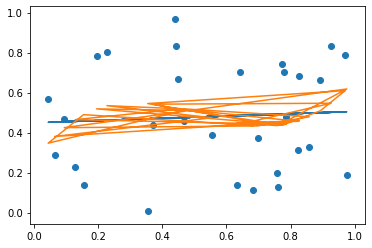

In [5]:
#Part A
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
X = rng.random(30)
Y = rng.random(30)

#Least squares line
A = np.vstack([X, np.ones(len(X))]).T
m, b = np.linalg.lstsq(A, Y, rcond=None)[0]
y_line = m*X + b

#Cubic polynomial
coeff = np.polyfit(X, Y, 3)
poly = np.poly1d(coeff)
y_poly = poly(X)

# MSE
mse_line = np.mean((Y - y_line)**2)
mse_poly = np.mean((Y - y_poly)**2)

#R^2
ss_tot = np.sum((Y - np.mean(Y))**2)

r2_line = 1 - np.sum((Y - y_line)**2)/ss_tot
r2_poly = 1 - np.sum((Y - y_poly)**2)/ss_tot

print("Linear MSE:", mse_line)
print("Polynomial MSE:", mse_poly)

print("Linear R2:", r2_line)
print("Polynomial R2:", r2_poly)

if r2_poly > r2_line:
    print("Polynomial is better")
else:
    print("Linear is better")

plt.scatter(X,Y)
plt.plot(X,y_line)
plt.plot(X,y_poly)
plt.show()

In [2]:
#Part B
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

X = rng.random(30)
Y = rng.random(30)

#Least squares line
A = np.vstack([X, np.ones(len(X))]).T
m, b = np.linalg.lstsq(A, Y, rcond=None)[0]
y_line = m*X + b

#function
def metrics(y_true, y_pred):
    mse = np.mean((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - np.sum((y_true - y_pred)**2)/ss_tot
    return mse, r2

mse_line, r2_line = metrics(Y, y_line)

print("Linear Fit")
print("MSE:", mse_line)
print("R2:", r2_line)
print()

for deg in range(1,10):

    coeff = np.polyfit(X, Y, deg)
    poly = np.poly1d(coeff)
    y_poly = poly(X)

    mse, r2 = metrics(Y, y_poly)

    print("Degree:", deg)
    print("MSE:", mse)
    print("R2:", r2)
    print()

Linear Fit
MSE: 0.07020026789999644
R2: 0.0038461902826909533

Degree: 1
MSE: 0.07020026789999644
R2: 0.0038461902826909533

Degree: 2
MSE: 0.07019937327318601
R2: 0.003858885190162642

Degree: 3
MSE: 0.06691050426682478
R2: 0.05052849897304801

Degree: 4
MSE: 0.06688928299201263
R2: 0.050829632492670695

Degree: 5
MSE: 0.0611514734698759
R2: 0.13225013110175154

Degree: 6
MSE: 0.06047449534741727
R2: 0.14185656646098843

Degree: 7
MSE: 0.05828799566036558
R2: 0.17288337103536755

Degree: 8
MSE: 0.05622689840967324
R2: 0.20213069358689806

Degree: 9
MSE: 0.05307377583367546
R2: 0.24687404230260857



Vandermonde Matrix:
[[1.00000000e+00 4.38037658e-02 1.91876990e-03 8.40493472e-05]
 [1.00000000e+00 6.38172561e-02 4.07264218e-03 2.59904849e-04]
 [1.00000000e+00 9.41773479e-02 8.86937286e-03 8.35294013e-04]
 [1.00000000e+00 1.28113633e-01 1.64131029e-02 2.10274223e-03]
 [1.00000000e+00 1.54289492e-01 2.38052474e-02 3.67289952e-03]
 [1.00000000e+00 1.94638708e-01 3.78842266e-02 7.37373691e-03]
 [1.00000000e+00 2.27238722e-01 5.16374367e-02 1.17340251e-02]
 [1.00000000e+00 3.54525968e-01 1.25688662e-01 4.45598946e-02]
 [1.00000000e+00 3.70798024e-01 1.37491175e-01 5.09814560e-02]
 [1.00000000e+00 4.38878440e-01 1.92614285e-01 8.45342568e-02]
 [1.00000000e+00 4.43414199e-01 1.96616152e-01 8.71823934e-02]
 [1.00000000e+00 4.50385938e-01 2.02847493e-01 9.13596584e-02]
 [1.00000000e+00 4.66721004e-01 2.17828495e-01 1.01665134e-01]
 [1.00000000e+00 5.54584787e-01 3.07564286e-01 1.70570474e-01]
 [1.00000000e+00 6.31664399e-01 3.98999913e-01 2.52034040e-01]
 [1.00000000e+00 6.43865120e-01 4.1

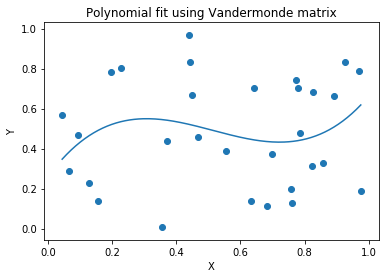

In [7]:
import numpy as np
import matplotlib.pyplot as plt

#same style data as challenge A
rng = np.random.default_rng(42)
X = rng.random(30)
Y = rng.random(30)

idx = np.argsort(X)
X = X[idx]
Y = Y[idx]

degree = 3

# Vandermonde matrix
V = np.vander(X, N=degree+1, increasing=True)

print("Vandermonde Matrix:")
print(V)

#solve for coefficients
coeff = np.linalg.lstsq(V, Y, rcond=None)[0]

print("Polynomial coefficients:")
print(coeff)

#predictions
Y_pred = V @ coeff

# MSE
mse = np.mean((Y - Y_pred)**2)

# R^2
ss_tot = np.sum((Y - np.mean(Y))**2)
ss_res = np.sum((Y - Y_pred)**2)
r2 = 1 - ss_res/ss_tot

print("MSE:", mse)
print("R^2:", r2)

x_smooth = np.linspace(min(X), max(X), 200)
V_smooth = np.vander(x_smooth, N=degree+1, increasing=True)
y_smooth = V_smooth @ coeff

plt.scatter(X, Y)
plt.plot(x_smooth, y_smooth)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Polynomial fit using Vandermonde matrix")
plt.show()